In [1]:
import torch 
import torch.nn as nn
#turn off scientific notation
torch.set_printoptions(sci_mode=False)

import copy
import torch.nn.functional as F
import tqdm
from torch_linear_assignment import batch_linear_assignment, assignment_to_indices
from typing import List, Tuple, Dict, Any, Literal, Optional, Union

from src.utils.normalizer import Normalizer

In [ ]:


class PermutedSparseWeight(nn.Module):
    original_weight: torch.FloatTensor
    importance_weight: Union[None, torch.FloatTensor] #shape of (d_in) if not None
    permutations_0: torch.LongTensor #shape of (n_permutations_0, d_out)
    permutations_1: torch.LongTensor #shape of (n_permutations_1, d_in)
    c_0: nn.Parameter #shape of (n_permutations_0, d_out)
    c_1: nn.Parameter #shape of (n_permutations_1, d_in)
    mask: torch.FloatTensor #shape of (d_out, d_in) with N of every M elements set to 1
    X: nn.Parameter #shape of (n_dense)
    block_size: int
    eps: float = 1e-8
    
    
    
    def __init__(self, original_weight: torch.FloatTensor, 
                 n_permutations_0: int, 
                 n_permutations_1: int,
                 N: int,
                 M: int,
                 block_size: int,
                 initalize_method: Literal["Greedy", "Random"] = "Greedy",
                 importance_weight: Optional[torch.FloatTensor] = None
    ):
        
        super(PermutedSparseWeight, self).__init__()
        
        
        d_out, d_in = original_weight.shape
        
        assert d_in % block_size == 0, f"d_in = {d_in} must be divisible by block_size = {block_size}"
        assert d_out % block_size == 0, f"d_out = {d_out} must be divisible by block_size = {block_size}"
        
        self.d_out = d_out
        self.d_in = d_in
        
        
        #initalize each of the permutation matricies
        self.register_buffer("permutations_0",
            torch.stack(
                [torch.arange(d_out)] +
            [
            (torch.stack([torch.randperm(block_size) for _ in range(d_out // block_size)]) + torch.arange(0, d_out, block_size).view(-1, 1)).view(-1) for _ in range(n_permutations_0 - 1)])
        )
        #shape of (n_permutations_0, d_out)
        
        self.register_buffer("permutations_1",
            torch.stack(
                [torch.arange(d_in)] +
            [
            (torch.stack([torch.randperm(block_size) for _ in range(d_in // block_size)]) + torch.arange(0, d_in, block_size).view(-1, 1)).view(-1) for _ in range(n_permutations_1 - 1)])
        )
        #shape of (n_permutations_1, d_in)
        
        #initalize the scaling factors
        # self.c_0 = nn.Parameter(torch.ones(n_permutations_0, d_out)/n_permutations_0, requires_grad=True)
        # self.c_1 = nn.Parameter(torch.ones(n_permutations_1, d_in)/n_permutations_1, requires_grad=True)
        self.c_0 = nn.Parameter(torch.concat(
            [torch.ones(1, d_out), torch.zeros(n_permutations_0 - 1, d_out)], dim=0
        ), requires_grad=True)
        self.c_1 = nn.Parameter(torch.concat(
            [torch.ones(1, d_in), torch.zeros(n_permutations_1 - 1, d_in)], dim=0
        ), requires_grad=True)
        
        # #set the first scaling factor to 1
        # self.c_0[0] = 1
        # self.c_1[0] = 1
        
        #initalize the mask
        self.register_buffer("mask",torch.zeros(d_out, d_in, dtype=torch.bool))
        self.mask = self.mask.view(-1, M)
        if initalize_method == "Random":
            indicies = torch.stack([torch.randperm(M)[:N] for _ in range(d_out*d_in // M)])
            print(indicies.shape)
            self.mask[torch.arange(self.mask.shape[0]).view(-1, 1), indicies] = True
        elif initalize_method == "Greedy":
            if importance_weight is None:
                importances = torch.abs(original_weight).view(-1, M)
            else:
                importances = torch.abs(original_weight**2 * importance_weight.unsqueeze(0)).view(-1, M)

            # get the smallest M-N elements along the last dimension
            smallest_idxs = torch.sort(importances, dim=-1).indices[..., :M-N]
            largest_idxs = torch.sort(importances, dim=-1).indices[..., -N:]
            
            # set the mask to True for the largest N elements
            self.mask[torch.arange(self.mask.shape[0]).view(-1, 1), largest_idxs] = True
            
        self.mask = self.mask.view(d_out, d_in)
        assert self.mask.sum() == N * (d_out * d_in)//M , f"mask should have {N * (d_out * d_in)//M} elements set to True, but has {self.mask.sum()} elements set to True"
        
        self.original_weight = original_weight.detach().clone()
        self.original_weight.requires_grad = False
        
        self.importance_weight = importance_weight
        # self.X = nn.Parameter(original_weight[self.mask].detach().clone())
        self.X = nn.Parameter(torch.randn(N * (d_out * d_in)//M) * torch.std(original_weight).item())
        
        with torch.no_grad():
            self.loss_scaling = {"mean":1.0, "sum": 1.0}    
            self.loss_scaling = {"mean":self.recon_loss(reduction = "mean", zero_sub = True).item(),
                                    "sum": self.recon_loss(reduction = "sum", zero_sub = True).item()}
        
        self.to(original_weight.device)
        self.block_size = block_size
        
            
        
        
        
        
    def forward(self, permutations_to_ignore: Tuple[set[int],set[int]] = [{},{}]):
        
        W_return = torch.zeros_like(self.original_weight)
        
        #get the masked weight
        W_return[self.mask] =  self.X
        # print(W_return)
        # print(self.original_weight)
        #apply the permutations
        
        #first apply along the 1st dimension
        perms_1 = [i for i in range(self.permutations_1.shape[0]) if i not in permutations_to_ignore[1]]
        #if all of the permutations are to be ignored
        if len(perms_1) > 0:
            # print("here")
            # print("self.c_1[perms_1]",self.c_1[perms_1])
            W_return = torch.einsum("ijk, jk-> ik", W_return[:, self.permutations_1[perms_1]], self.c_1[perms_1])
        # print(W_return)
        #then apply along the 0th dimension
        perms_0 = [i for i in range(self.permutations_0.shape[0]) if i not in permutations_to_ignore[0]]
        
        #if all of the permutations are to be ignored
        if len(perms_0) > 0:
            W_return = torch.einsum("ijk, ij-> jk", W_return[self.permutations_0[perms_0],:], self.c_0[perms_0])
        # print(W_return)
        # raise ValueError("No permutations to apply")
        #return the weight
        return W_return
        
    @torch.no_grad()
    def greedy_optimize_permutation(self, dim: Literal[0, 1]):
        i = 100
        #randomly select a permutation
        
        selected_permutation = torch.randint(0, self.permutations_0.shape[0], (1,)).item() if dim == 0 else torch.randint(0, self.permutations_1.shape[0], (1,)).item()
        
        if dim == 0:
            #we ignore this permutation and calculate the elementwise loss when we are only consider the other permutations
            recon_loss = self.original_weight - self.forward(permutations_to_ignore=({selected_permutation}, {})) #this is of shape (d_out, d_in)
            

            #get the pre_permutation weight
            pre_permutation_weight = self.forward(permutations_to_ignore=({range(self.permutations_0.shape[0])}, {})) #this is of shape (d_out, d_in)
            
            if self.importance_weight is not None:
                recon_loss = recon_loss * torch.sqrt(self.importance_weight.unsqueeze(0))
                pre_permutation_weight = pre_permutation_weight * torch.sqrt(self.importance_weight.unsqueeze(0))
                
            orig_scales = self.c_0[selected_permutation]
        else:
            #we ignore this permutation and calculate the elementwise loss when we are only consider the other permutations
            # recon_loss = self.recon_loss(permutations_to_ignore=({}, {selected_permutation}), reduction="none")
            recon_loss = self.original_weight -  self.forward(permutations_to_ignore=({}, {selected_permutation})) #this is of shape (d_out, d_in)
            #get the pre_permutation weight
            pre_permutation_weight = self.forward(permutations_to_ignore=({}, {range(self.permutations_1.shape[0])}))
            
            #transpose both of these to allow us to use the same code 
            if self.importance_weight is not None:
                recon_loss = recon_loss * torch.sqrt(self.importance_weight.unsqueeze(0))
                pre_permutation_weight = pre_permutation_weight * torch.sqrt(self.importance_weight.unsqueeze(0))
                
            recon_loss = recon_loss.transpose(0,1) #shape of (d_in, d_out)
            pre_permutation_weight = pre_permutation_weight.transpose(0,1)
            
            orig_scales = self.c_1[selected_permutation]
        
        # print("recon_loss", recon_loss.shape)
        #from now lets denote the shapes of recon_loss and pre_permutation_weight as (d_1, d_2) where we want to find a permutation of d_1
        d_1, d_2 = recon_loss.shape
        # print("d_1, d_2", d_1, d_2)
        #for both, break it into batches
        recon_loss = recon_loss.view((-1, self.block_size, d_2)) #shape of (d_1/m, b, d_2)
        pre_permutation_weight = pre_permutation_weight.view((-1, self.block_size, d_2)) #shape of (d_1/m, b, d_2)
        
        #calculate the optimal scaling and the resulting loss 
        
        #the l2 loss is given by ||x x^Ty/(x^T x) - y||^2
        # where x is the pre_permutation_weight and y is the recon_loss
        #the second order term is  (x^T y)^2
        #the first order term is -2 (x^T y)^2
        #we will ignore the constant term
        
        #calculate the optimal scaling by first precomputing the inner product
        recon_pre_perm_inner = torch.bmm(recon_loss, pre_permutation_weight.transpose(1,2)) #shape of (d_1/m, b, b)
    
        perm_perm_inner = torch.sum(pre_permutation_weight**2, dim = -1).unsqueeze(1) #shape of (d_1/m, 1, b)
        recon_loss_inner = torch.sum(recon_loss**2, dim = -1).unsqueeze(2) #shape of (d_1/m, b, 1)
        cost = (- 1/(perm_perm_inner)) * recon_pre_perm_inner**2 + recon_loss_inner#shape of (d_1/m, b, b)
        # cost = perm_perm_inner.unsqueeze(1) - 2*recon_pre_perm_inner + recon_loss_inner.unsqueeze(2) #shape of (d_1/m, b, b)  
        # print( torch.sum(((pre_permutation_weight.unsqueeze(1) - recon_loss.unsqueeze(2))**2)[i], dim = -1))
        # print(cost[i])
        #use the linear assignment to get the optimal assignments
        # print(cost.shape)
        # print(cost)
        assignments = batch_linear_assignment(cost)
        row_ind, col_ind = assignment_to_indices(assignments)
        # print(row_ind[i])
        # print(col_ind.shape)
        # print(torch.argsort(col_ind, dim = 1))
        # optimal_costs = cost[torch.arange(recon_loss.shape[0]).unsqueeze(1), row_ind, col_ind] #shape of (d_1/m, b)
        scales = (recon_pre_perm_inner/(perm_perm_inner))[torch.arange(recon_loss.shape[0]).unsqueeze(1), row_ind, col_ind] #shape of (d_1/m, b)
        # print("scales", scales.shape)
        scale_mask = (col_ind == torch.arange(self.block_size, device = col_ind.device)).all(dim = 1) #shape of (d_1/m)
        
        scales[scale_mask] = orig_scales.view_as(scales)[scale_mask] #shape of (d_1/m, b)
        
        #convert these indicies to the overall indicies
        overall_indicies = col_ind + torch.arange(0, recon_loss.shape[0], device = col_ind.device).view(-1, 1) * self.block_size #shape of (d_1/m, b)
        # print("expected_loss", cost[i][row_ind[i], col_ind[i]])
        # print((pre_permutation_weight[i,col_ind[i]]).shape)
        # print("loss_computed", torch.sum(
        #     (pre_permutation_weight[i,col_ind[i]]* scales[i].unsqueeze(1)
        #      - recon_loss[i,:])**2, dim = 1))
        # print((recon_pre_perm_inner/(recon_recon_inner + self.eps)).shape)
        # scales = scales[torch.arange(recon_loss.shape[0]).unsqueeze(1), row_ind, col_ind] #shape of (d_1/m, b)
        # print("scales",scales[i])
        #put these back into the corresponding places
        if dim == 0:
            # print(overall_indicies)
            self.permutations_0[selected_permutation] = overall_indicies.view(-1) #shape of (d_out)
            
            self.c_0[selected_permutation] = scales.view(-1)
            
            # loss = torch.sum(self.recon_loss(reduction = "none").view(-1, self.block_size, self.d_in), dim = 2) #shape of (d_1/m, b)
            # print("loss gotten", torch.sum(loss[i], dim = 1))
            # self.permutations_0[selected_permutation] = overall_indicies.view(-1) #shape of (d_out)
            # self.c_0[selected_permutation] = scales.view(-1) #shape of (d_out)
        else:
            
            # s = self.forward(permutations_to_ignore=({}, {selected_permutation})).T.view_as(recon_loss) #shape of (d_1/m, b, d_2)
            # # print(pre_permutation_weight[torch.arange(recon_loss.shape[0]).unsqueeze(1), col_ind].shape)
            # # print(scales.unsqueeze(1).shape)
            # expected_weight = (s  + pre_permutation_weight[torch.arange(recon_loss.shape[0]).unsqueeze(1), col_ind] * scales.unsqueeze(2)) #shape of (d_1/m, b, d_2)
            # expected_weight = expected_weight.view(self.d_in,self.d_out).T
            # print("expected_weight", expected_weight[:, i*self.block_size:(i+1)*self.block_size])
            # print("expected_l2  loss", torch.sum((expected_weight - self.original_weight)**2, dim = 0)[i*self.block_size:(i+1)*self.block_size])
            # print("expected overall loss", torch.mean((expected_weight - self.original_weight)**2))
            self.permutations_1[selected_permutation] = overall_indicies.view(-1) #shape of (d_in)
            
            self.c_1[selected_permutation] = scales.view(-1) #shape of (d_in)
            
            # print("new_weight_block", self()[:, i*self.block_size:(i+1)*self.block_size])
            
            # self.c_1[selected_permutation] = scales.view(-1)
        
            # loss = torch.sum(self.recon_loss(reduction = "none").T.view(-1, self.block_size, self.d_in), dim = 2) #shape of (d_1/m, b, d_2)
            # print("loss gotten", torch.sum(loss[i], dim = 1))
        # assert torch.allclose(loss, optimal_costs, atol = 1e-4, rtol = 1e-4), f"losses are not close {loss} {optimal_costs}"
        
    def recon_loss(self, reduction: Literal["mean", "sum", "none"] = "mean",
                   zero_sub:bool = False,
                   **kwargs):
        
        if zero_sub:
            recon_weight = torch.zeros_like(self.original_weight) #used to get the loss scaling
        else:
            recon_weight = self(**kwargs)
        
        #reconstruction loss
        recon_loss_elementwise = (recon_weight - self.original_weight) ** 2 if self.importance_weight is None else (recon_weight - self.original_weight) ** 2 * self.importance_weight.unsqueeze(0)
        
        if reduction == "mean":
            return recon_loss_elementwise.mean()/self.loss_scaling["mean"] #scale the loss by the scaling factor
        elif reduction == "sum":
            return recon_loss_elementwise.sum()/self.loss_scaling["sum"] #scale the loss by the scaling factor
        elif reduction == "none":
            return recon_loss_elementwise

        

In [4]:
device = "cuda:7"

weight_path = "./models/meta-llama/Llama-2-7b-hf/original_weights/layer_20/self_attn.q_proj.pt"
hessian_diag = weight_path.replace("original_weights", "hessianDiags/seed_0/pajama/128")


weight = torch.load(weight_path, map_location=device)["weight"].to(torch.float32).detach()
hessian_diag = torch.load(hessian_diag, map_location=device)["hessianDiag"].to(torch.float32    )


hessian_diag = hessian_diag/torch.median(hessian_diag)

normalizer, normalized_weight = Normalizer.normalize_init(weight, norm_order=[0,1], zero = [False, False])

In [5]:
hessian_diag

tensor([1.0203, 1.2171, 1.1435,  ..., 0.9895, 0.9098, 0.9699], device='cuda:7')

In [6]:
weight.shape[0]/32

128.0

In [ ]:
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

P = PermutedSparseWeight(original_weight=normalized_weight,
                            n_permutations_0=8,
                            n_permutations_1=8,
                            N=2,
                            M=4,
                            block_size=32,
                            initalize_method="Greedy",
                            importance_weight=None
                            )
P.to(device)

l = [P.recon_loss(reduction="mean").item()]
print("initial loss", l[0])
optimizer = torch.optim.Adam(P.parameters(), lr=1e-3)
n_adam_steps = 10
n_permutation_to_change = 4
for i in tqdm.tqdm(range(100)):

    


            
        #reinitalize a new optimizer
    for j in range(n_adam_steps):
        optimizer.zero_grad()
        loss = P.recon_loss(reduction="mean")
        loss.backward()
        optimizer.step()
        l.append(loss.item())
    if n_adam_steps > 0:
        print(f"loss after {n_adam_steps} steps = {loss.item()}")
        
    #randomly select a permutation to optimize
    with torch.no_grad():
        for j in range(n_permutation_to_change):
            prev_state_dict = copy.deepcopy(P.state_dict()) 
            #randomly select a dimension to optimize
            permutation_dim = 0 if torch.randint(0, 2, (1,)).item() == 0 else 1
            # permutation_dim = 0|
            # print(f"Greedy optimizing permutation {permutation_dim}")

            prev_loss = P.recon_loss(reduction="mean")
            P.greedy_optimize_permutation(permutation_dim)
            new_loss = P.recon_loss(reduction="mean")
            # assert new_loss <= prev_loss + 1e-8, f"Loss should decrease but is {new_loss} > {prev_loss}"
            # print(f"prev_loss = {prev_loss.item()}, new_loss = {new_loss.item()}")
            if new_loss - 1e-3> prev_loss:
                print("Loss increased, reverting to previous state")
                P.load_state_dict(prev_state_dict)
                assert P.recon_loss() == prev_loss, f"Loss should be the same but is {P.recon_loss()} != {prev_loss}"
                # P.load_state_dict(prev_state_dict)
                # print("prev_loss", prev_loss.item())
                # print("new_loss", new_loss.item())
            else:
                l.append(new_loss.item())
            # break
            # break
            # assert new_loss <= prev_loss + 1e-8, f"Loss should decrease but is {new_loss} > {prev_loss}"
            # break
            # l.append(new_loss.item())


initial loss 0.13200132548809052


  0%|          | 0/100 [00:00<?, ?it/s]

loss after 10 steps = 0.13099215924739838


  2%|▏         | 2/100 [00:02<01:57,  1.20s/it]

loss after 10 steps = 0.12970805168151855


...

loss after 10 steps = 0.12590667605400085
loss after 10 steps = 0.12590694427490234
Loss increased, reverting to previous state


 99%|█████████▉| 99/100 [01:30<00:00,  1.10it/s]

loss after 10 steps = 0.12590882182121277
loss after 10 steps = 0.12590762972831726
Loss increased, reverting to previous state


100%|██████████| 100/100 [01:31<00:00,  1.09it/s]

Loss increased, reverting to previous state


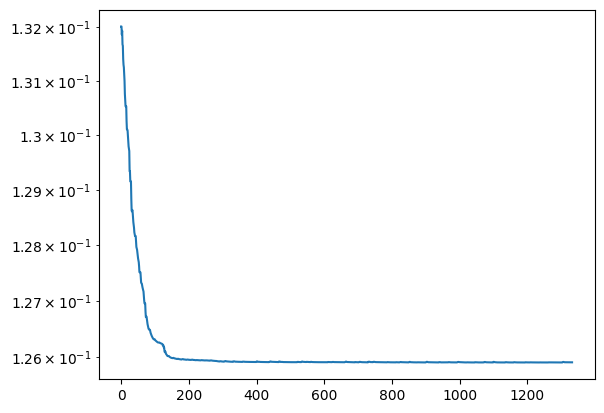

In [8]:
import matplotlib.pyplot as plt 
plt.plot(l)
plt.yscale("log")
# plt.xscale("log")

In [9]:
P()

tensor([[     0.0002,     -0.0025,      0.0322,  ...,      0.0219,
              0.0003,     -0.0400],
        [    -0.0011,     -0.0333,      0.0020,  ...,      0.0018,
             -0.0127,      0.0161],
        [    -0.0014,     -0.0095,     -0.0137,  ...,      0.0246,
              0.0012,      0.0026],
        ...,
        [    -0.0127,     -0.0245,      0.0019,  ...,     -0.0001,
              0.0117,      0.0006],
        [    -0.0393,     -0.0086,      0.0025,  ...,      0.0053,
              0.0103,     -0.0020],
        [     0.0117,      0.0034,     -0.0042,  ...,     -0.0115,
             -0.0000,      0.0012]], device='cuda:7', grad_fn=<ViewBackward0>)

In [10]:
P.original_weight

tensor([[ 0.0024, -0.0102,  0.0312,  ...,  0.0223,  0.0041, -0.0403],
        [ 0.0101, -0.0327,  0.0164,  ..., -0.0142, -0.0150,  0.0163],
        [ 0.0055, -0.0093, -0.0134,  ...,  0.0249, -0.0027, -0.0075],
        ...,
        [-0.0130, -0.0242,  0.0065,  ..., -0.0021,  0.0117,  0.0028],
        [-0.0390, -0.0093,  0.0064,  ...,  0.0045,  0.0105,  0.0041],
        [ 0.0121, -0.0009, -0.0040,  ..., -0.0102, -0.0063, -0.0014]],
       device='cuda:7')

In [24]:
P.permutations_0    

tensor([[   0,    1,    2,  ..., 4093, 4094, 4095],
        [   8,   22,   29,  ..., 4080, 4095, 4065],
        [   5,   13,    4,  ..., 4072, 4087, 4089],
        ...,
        [   3,    0,   16,  ..., 4079, 4066, 4073],
        [  25,    3,    7,  ..., 4091, 4069, 4075],
        [   5,    0,    1,  ..., 4089, 4082, 4087]], device='cuda:7')

In [57]:
import torch

M = torch.tensor([[1, 2, 3],
                  [4, 5, 6],
                  [1, 2, 3]])

M = torch.stack([M, M], dim=0)

v = torch.tensor([1, 2, 3])

mask = (M == v.unsqueeze(0).unsqueeze(2)).all(dim=1)
print(mask)  # Output: tensor([ True, False,  True])

tensor([[False, False, False],
        [False, False, False]])
